# <font color="blue">**Light Cone of Quantum Scrambling**</font>

Alexander Del Toro Barba, PhD

In [11]:
!pip install cirq cirq-ionq -q
# ⚠️ Optional: Restart kernel

In [12]:
import cirq_ionq # https://docs.ionq.com/sdks/cirq
import cirq      # https://quantumai.google/cirq/hardware/ionq/circuits

from scipy.linalg import norm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

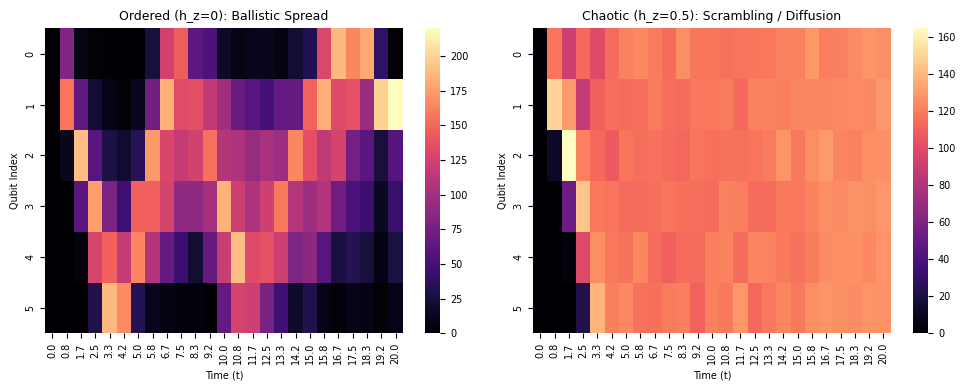

In [10]:
# OTOC for all qubits over time. Ordered vs Chaotic
def get_unitary_from_circuit(qubits, t, h_x, h_z, steps=25):
    """
    Creates the Unitary Matrix U(t) for a specific Hamiltonian setup.
    H = Sum(Zi Zj) + h_x * Sum(Xi) + h_z * Sum(Zi)
    """
    circuit = cirq.Circuit()
    dt = t / steps
    n = len(qubits)

    for _ in range(steps):
        # 1. Interaction (ZZ) - The "Scrambler"
        for i in range(n - 1):
            circuit.append(cirq.CNOT(qubits[i], qubits[i+1]))
            circuit.append(cirq.rz(rads=2 * dt).on(qubits[i+1]))
            circuit.append(cirq.CNOT(qubits[i], qubits[i+1]))

        # 2. Transverse Field (X) - The "Driver"
        if h_x != 0:
            for i in range(n):
                circuit.append(cirq.rx(rads=2 * h_x * dt).on(qubits[i]))

        # 3. Longitudinal Field (Z) - The "Chaos Generator"
        # Adding this term breaks integrability and causes chaos.
        if h_z != 0:
            for i in range(n):
                circuit.append(cirq.rz(rads=2 * h_z * dt).on(qubits[i]))

    # Extract the full unitary matrix (2^N x 2^N)
    return cirq.unitary(circuit)

def calculate_otoc_heatmap(num_qubits, h_x, h_z, t_max, t_steps):
    """
    Calculates OTOC for all qubits over time to visualize the Light Cone.
    """
    qubits = cirq.LineQubit.range(num_qubits)
    times = np.linspace(0, t_max, t_steps)
    # Matrix to store results: Rows = Qubits, Cols = Time
    heatmap_data = np.zeros((num_qubits, t_steps))

    # V is always X on the first qubit (The "Butterfly")
    op_list_V = [np.eye(2)] * num_qubits
    op_list_V[0] = np.array([[0, 1], [1, 0]]) # Pauli X
    V = op_list_V[0]
    for i in range(1, num_qubits):
        V = np.kron(V, op_list_V[i])

    #print(f"Generating Heatmap (h_z={h_z})...")

    for t_idx, t in enumerate(times):
        if t == 0: continue

        # Get the global Unitary for this time point
        U = get_unitary_from_circuit(qubits, t, h_x, h_z) # Using previous function
        U_dag = U.conj().T

        # Calculate OTOC for each qubit j as the "Probe"
        for j in range(num_qubits):
            # W is Z on qubit j
            op_list_W = [np.eye(2)] * num_qubits
            op_list_W[j] = np.array([[1, 0], [0, -1]]) # Pauli Z

            # Construct W matrix
            W = op_list_W[0]
            for k in range(1, num_qubits):
                W = np.kron(W, op_list_W[k])

            # Heisenberg evolution: W(t) = U^dag * W * U
            W_t = U_dag @ W @ U

            # Commutator magnitude
            commutator = W_t @ V - V @ W_t
            heatmap_data[j, t_idx] = np.linalg.norm(commutator) ** 2

    return times, heatmap_data

# --- Execution ---
n_qubits = 6 # Kept small for simulation speed
t_max = 20.0
t_steps = 25

# Generate data for Chaotic vs Ordered
_, data_ordered = calculate_otoc_heatmap(n_qubits, 1.0, 0.0, t_max, t_steps)
times, data_chaotic = calculate_otoc_heatmap(n_qubits, 1.0, 0.5, t_max, t_steps)

# --- Plotting ---

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Define your desired font size
small_size = 7

# Plot 1
sns.heatmap(data_ordered, ax=ax1, cmap='magma', xticklabels=np.round(times, 1))
ax1.set_title("Ordered (h_z=0): Ballistic Spread", fontsize=small_size + 2)
ax1.set_xlabel("Time (t)", fontsize=small_size)
ax1.set_ylabel("Qubit Index", fontsize=small_size)
ax1.tick_params(axis='both', labelsize=small_size)

# Adjust Colorbar 1
cbar1 = ax1.collections[0].colorbar
cbar1.ax.tick_params(labelsize=small_size)

# Plot 2
sns.heatmap(data_chaotic, ax=ax2, cmap='magma', xticklabels=np.round(times, 1))
ax2.set_title("Chaotic (h_z=0.5): Scrambling / Diffusion", fontsize=small_size + 2)
ax2.set_xlabel("Time (t)", fontsize=small_size)
ax2.set_ylabel("Qubit Index", fontsize=small_size)
ax2.tick_params(axis='both', labelsize=small_size)

# Adjust Colorbar 2
cbar2 = ax2.collections[0].colorbar
cbar2.ax.tick_params(labelsize=small_size)

plt.tight_layout()
plt.show()

<font color="blue">*Corrected version: exact time evolution and normalized OTOC*</font>

The cell above is kept for reference. The copy below changes three things:

1. **Exact dynamics.** Above, the Trotter step is `dt = t/25`, so it changes with $t$ ($dt = 0.8$ at $t = 20$). Every column of the heatmap is then a different Floquet circuit with a large Trotter error, not one time evolution. Below, $U(t) = e^{-iHt}$ is computed exactly from the eigendecomposition of $H$ ($N = 8$, a 256×256 matrix).
2. **Normalization.** Above, $\|[W(t),V]\|_F^2$ grows with $2^N$. Below, $C_j(t) = 1 - \mathrm{Re}\,F_j(t)$ with $F_j(t) = 2^{-N}\,\mathrm{Tr}[W_j(t)\,V\,W_j(t)\,V]$. $C = 0$ means the operators commute, $C = 1$ means fully scrambled ($F = 0$). For Pauli operators, $\|[W,V]\|_F^2 = 2^{N+1}\,C$.
3. **Interpretation.** Both phases show a ballistic light cone. The difference lies behind the front: in the integrable chain ($h_z = 0$, free fermions after a Jordan–Wigner transformation) the OTOC relaxes back towards 0 once the quasiparticles have passed, while in the chaotic chain it saturates near the scrambled value $C \approx 1$ (late-time average at the far end: 0.30 vs. 0.91). "Diffusive" describes only the broadening of the front, not its motion.

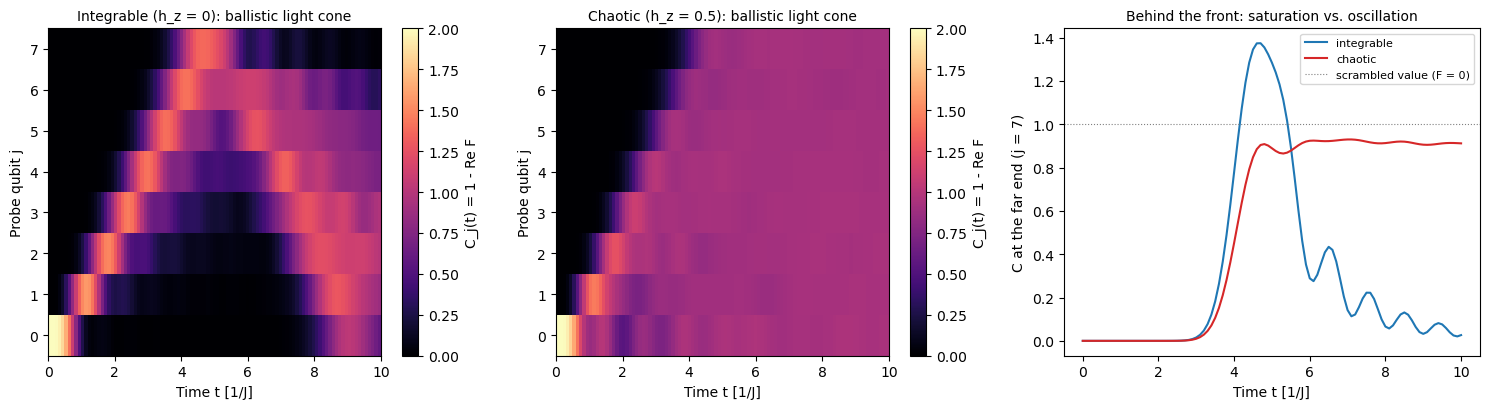

Late-time average of C (t > 5) at the far end:  integrable 0.30  |  chaotic 0.91


In [13]:
# OTOC light cone - corrected version (exact time evolution, normalized OTOC)
# Differences to the cell above:
#   1. U(t) = exp(-iHt) exactly (eigendecomposition), so all time points belong to the same dynamics
#      (above, dt = t/25 changes with t: every column is a different Floquet circuit with large Trotter error)
#   2. Normalized OTOC C_j(t) = 1 - Re F_j(t),  F_j(t) = Tr[W_j(t) V W_j(t) V] / 2^N,  C in [0, 2]
#   3. Titles: both phases spread ballistically; the difference is what happens behind the front
from scipy.linalg import eigh

X = np.array([[0, 1], [1, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)

def site_op(op, j, n):
    """Single-qubit operator `op` on qubit j of an n-qubit chain (qubit 0 = leftmost factor)."""
    mats = [np.eye(2, dtype=complex)] * n
    mats[j] = op
    out = mats[0]
    for m in mats[1:]:
        out = np.kron(out, m)
    return out

def ising_hamiltonian(n, h_x, h_z, J=1.0):
    """H = J Σ Z_i Z_{i+1} + h_x Σ X_i + h_z Σ Z_i  (open chain). h_z = 0: integrable, h_z != 0: chaotic."""
    H = sum(J * site_op(Z, i, n) @ site_op(Z, i + 1, n) for i in range(n - 1))
    H = H + sum(h_x * site_op(X, i, n) + h_z * site_op(Z, i, n) for i in range(n))
    return H

def otoc_heatmap(n, h_x, h_z, times):
    """C_j(t) = 1 - Re Tr[W_j(t) V W_j(t) V] / 2^n with V = X_0 (butterfly) and W_j = Z_j (probe)."""
    E, S = eigh(ising_hamiltonian(n, h_x, h_z))
    V = site_op(X, 0, n)
    Ws = [site_op(Z, j, n) for j in range(n)]
    C = np.zeros((n, len(times)))
    for k, t in enumerate(times):
        U = (S * np.exp(-1j * E * t)) @ S.conj().T
        for j, W in enumerate(Ws):
            W_t = U.conj().T @ W @ U                        # Heisenberg picture
            F = np.trace(W_t @ V @ W_t @ V).real / 2 ** n
            C[j, k] = 1 - F
    return C

# --- Execution ---
N_QUBITS = 8          # exact diagonalization: 2^8 = 256, runs in seconds
T_MAX, T_STEPS = 10.0, 101
H_X, H_Z = 1.0, 0.5
times = np.linspace(0, T_MAX, T_STEPS)

C_int = otoc_heatmap(N_QUBITS, H_X, 0.0, times)
C_chaos = otoc_heatmap(N_QUBITS, H_X, H_Z, times)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, C, title in [(axes[0], C_int, f"Integrable (h_z = 0)"), (axes[1], C_chaos, f"Chaotic (h_z = {H_Z})")]:
    im = ax.imshow(C, aspect="auto", origin="lower", cmap="magma", vmin=0, vmax=2,
                   extent=[times[0], times[-1], -0.5, N_QUBITS - 0.5])
    ax.set_title(f"{title}: ballistic light cone", fontsize=10)
    ax.set_xlabel("Time t [1/J]")
    ax.set_ylabel("Probe qubit j")
    fig.colorbar(im, ax=ax, label="C_j(t) = 1 - Re F")
far = N_QUBITS - 1
axes[2].plot(times, C_int[far], label="integrable", c="tab:blue")
axes[2].plot(times, C_chaos[far], label="chaotic", c="tab:red")
axes[2].axhline(1, color="grey", ls=":", lw=0.8, label="scrambled value (F = 0)")
axes[2].set_xlabel("Time t [1/J]")
axes[2].set_ylabel(f"C at the far end (j = {far})")
axes[2].set_title("Behind the front: saturation vs. oscillation", fontsize=10)
axes[2].legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"Late-time average of C (t > {T_MAX / 2:.0f}) at the far end:  integrable {C_int[far, T_STEPS // 2:].mean():.2f}  |  chaotic {C_chaos[far, T_STEPS // 2:].mean():.2f}")

<font color="blue">*1. Butterfly velocity: measured light cone vs. exact theory*</font>

For a brickwork circuit of Haar-random two-qubit gates, the circuit-averaged OTOC is known exactly: the right end of the spreading operator performs a biased random walk. This gives the butterfly velocity $v_B = (q^2-1)/(q^2+1) = 3/5$ for qubits ($q = 2$), in units where the strict light cone moves one site per layer, and a front that broadens as $\sqrt{t}$ (Nahum, Vijay, Haah, PRX 8, 021014 (2018); von Keyserlingk, Rakovszky, Pollmann, Sondhi, PRX 8, 021013 (2018)).

The cell simulates 12 qubits, 20 random circuits and 16 layers. A single Haar-random state replaces the normalized trace (typicality, error $\sim 2^{-N/2}$). The front is the position where the averaged $C_j(t)$ crosses 1/2, and a linear fit gives $v_B$.

* **Result:** $v_B = 0.595$ sites/layer (12 qubits, 20 circuits, ~10 s) and $0.594$ (14 qubits, 20 circuits, 20 layers, ~2 min), against the theory value 0.600.
* The profiles on the right show the front moving and broadening; the step pattern comes from the brickwork, where a gate covers two sites.

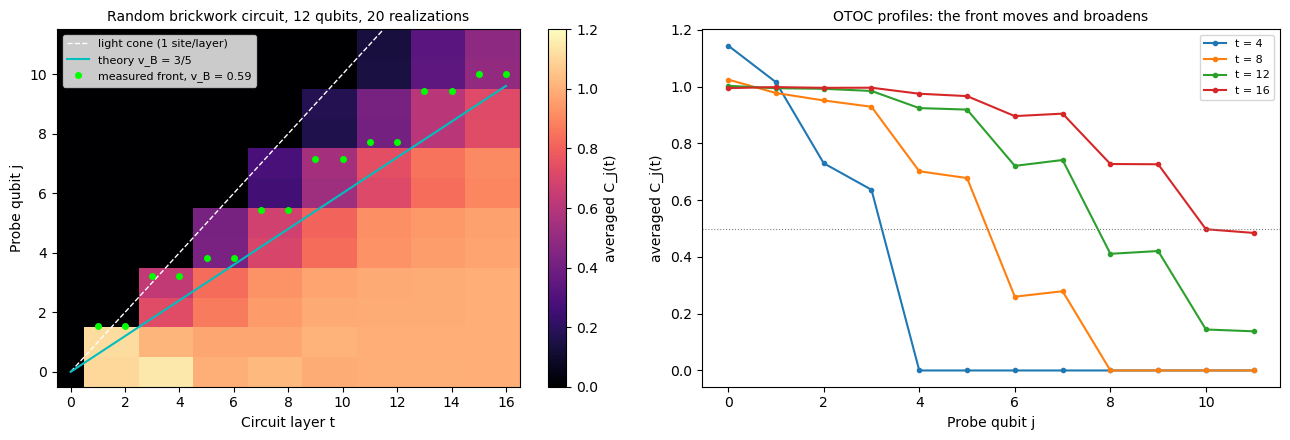

✅ Butterfly velocity (fit over layers 3-16)
  Measured:  v_B = 0.595 sites/layer
  Theory:    v_B = (q² - 1)/(q² + 1) = 0.600   (q = 2, Haar-random gates)
  Light cone:     1 site/layer   ->  information spreads at 60% of the maximal speed


In [14]:
# 1. Butterfly velocity in random brickwork circuits: numerics vs. exact theory v_B = (q^2 - 1) / (q^2 + 1) = 3/5
from scipy.stats import unitary_group

def apply_2q(psi, gate, i, n):
    """Apply a 4x4 gate to qubits (i, i+1) of an n-qubit state vector."""
    psi = psi.reshape([2] * n)
    psi = np.moveaxis(psi, [i, i + 1], [0, 1]).reshape(4, -1)
    psi = (gate @ psi).reshape([2, 2] + [2] * (n - 2))
    return np.moveaxis(psi, [0, 1], [i, i + 1]).reshape(-1)

def apply_1q(psi, op, j, n):
    psi = np.moveaxis(psi.reshape([2] * n), j, 0)
    psi = np.tensordot(op, psi, axes=1)
    return np.moveaxis(psi, 0, j).reshape(-1)

def brickwork(n, depth, rng):
    """Random circuit: layer t applies Haar-random 2-qubit gates on bonds (i, i+1) with i = t mod 2, t mod 2 + 2, ..."""
    return [[(i, unitary_group.rvs(4, random_state=rng)) for i in range(t % 2, n - 1, 2)] for t in range(depth)]

def evolve(psi, layers, n, dagger=False):
    """U|psi> (or U^dagger|psi>) for the circuit U = L_T ... L_1."""
    seq = reversed(layers) if dagger else layers
    for layer in seq:
        for i, g in layer:
            psi = apply_2q(psi, g.conj().T if dagger else g, i, n)
    return psi

def otoc_profile(n, layers, psi):
    """C_j = 1 - Re <psi| V(t) W_j V(t) W_j |psi>,  V = Z_0 (butterfly, evolved), W_j = Z_j (probe).
    A single Haar-random |psi> replaces the normalized trace (typicality, error ~ 2^(-n/2))."""
    C = np.zeros(n)
    for j in range(n):
        phi = apply_1q(psi, Z, j, n)                                   # W_j
        for step in range(2):                                          # (V(t) W_j) twice
            phi = evolve(phi, layers, n)                               # U
            phi = apply_1q(phi, Z, 0, n)                               # V
            phi = evolve(phi, layers, n, dagger=True)                  # U^dagger  -> V(t)
            if step == 0:
                phi = apply_1q(phi, Z, j, n)                           # W_j
        C[j] = 1 - np.vdot(psi, phi).real
    return C

# --- Execution ---
N_RC       = 12     # qubits (state vector 2^12 = 4096)
DEPTH      = 16     # circuit layers; the strict light cone moves 1 site per layer
N_CIRCUITS = 20     # circuit realizations to average over
rng = np.random.default_rng(1)

C_rc = np.zeros((N_CIRCUITS, DEPTH + 1, N_RC))
for r in range(N_CIRCUITS):
    circuit = brickwork(N_RC, DEPTH, rng)
    psi0 = rng.normal(size=2 ** N_RC) + 1j * rng.normal(size=2 ** N_RC)   # Haar-random state
    psi0 /= np.linalg.norm(psi0)
    for t in range(1, DEPTH + 1):
        C_rc[r, t] = otoc_profile(N_RC, circuit[:t], psi0)
C_mean = C_rc.mean(axis=0)                                             # average over circuits

# Front position: where the averaged OTOC crosses half of its scrambled value C = 1
x_front = np.array([np.interp(0.5, C_mean[t][::-1], np.arange(N_RC)[::-1]) if C_mean[t].max() > 0.5 else np.nan
                    for t in range(DEPTH + 1)])
fit = (np.arange(DEPTH + 1) >= 3) & (x_front < N_RC - 2)              # skip start-up and the right boundary
v_fit, x0 = np.polyfit(np.arange(DEPTH + 1)[fit], x_front[fit], 1)
V_THEORY = (2 ** 2 - 1) / (2 ** 2 + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
im = axes[0].imshow(C_mean.T, aspect="auto", origin="lower", cmap="magma", vmin=0, vmax=1.2,
                    extent=[-0.5, DEPTH + 0.5, -0.5, N_RC - 0.5])
tt = np.linspace(0, DEPTH, 100)
axes[0].plot(tt, tt, "w--", lw=1, label="light cone (1 site/layer)")
axes[0].plot(tt, V_THEORY * tt, "c-", lw=1.5, label=f"theory v_B = 3/5")
axes[0].plot(np.arange(DEPTH + 1), x_front, "o", c="lime", ms=4, label=f"measured front, v_B = {v_fit:.2f}")
axes[0].set_ylim(-0.5, N_RC - 0.5)
axes[0].set_xlabel("Circuit layer t")
axes[0].set_ylabel("Probe qubit j")
axes[0].set_title(f"Random brickwork circuit, {N_RC} qubits, {N_CIRCUITS} realizations", fontsize=10)
axes[0].legend(fontsize=8, loc="upper left")
fig.colorbar(im, ax=axes[0], label="averaged C_j(t)")
for t in [4, 8, 12, 16]:
    if t <= DEPTH:
        axes[1].plot(np.arange(N_RC), C_mean[t], "o-", ms=3, label=f"t = {t}")
axes[1].axhline(0.5, color="grey", ls=":", lw=0.8)
axes[1].set_xlabel("Probe qubit j")
axes[1].set_ylabel("averaged C_j(t)")
axes[1].set_title("OTOC profiles: the front moves and broadens", fontsize=10)
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"✅ Butterfly velocity (fit over layers {np.arange(DEPTH + 1)[fit].min()}-{np.arange(DEPTH + 1)[fit].max()})")
print(f"  Measured:  v_B = {v_fit:.3f} sites/layer")
print(f"  Theory:    v_B = (q² - 1)/(q² + 1) = {V_THEORY:.3f}   (q = 2, Haar-random gates)")
print(f"  Light cone:     1 site/layer   ->  information spreads at {V_THEORY:.0%} of the maximal speed")

<font color="blue">*2. Black holes: recovering information with the Hayden–Preskill protocol*</font>

Hayden and Preskill (JHEP 2007) showed that a diary thrown into an old black hole, one that is already maximally entangled with its early radiation, can be recovered from only a few more Hawking qubits than the diary contains, once the black hole has scrambled it. Yoshida and Kitaev (arXiv:1710.03363) gave an explicit decoder. Bob applies $U^*$ to his copy of the early radiation together with one half of a fresh EPR pair $(A', R')$, then projects the Hawking qubit $D$ and its partner $D'$ onto an EPR pair. For unitary $U$:

* the success probability $P_\mathrm{EPR}$ equals the OTOC averaged over all Pauli operators on $A$ and $D$;
* the fidelity of $(R, R')$ with an EPR pair is $F_\mathrm{EPR} = 1/(d_A^2\,P_\mathrm{EPR})$;
* a perfect scrambler gives $P = 1/d_A^2 = 1/4$ and $F = 1$; no scrambling gives $P = 1$ and $F = 1/4$.

Yoshida and Yao (PRX 9, 011006 (2019)) pointed out that a decaying OTOC alone cannot distinguish scrambling from decoherence, whereas $F_\mathrm{EPR}$ can. Landsman et al. (Nature 567, 61 (2019)) ran this protocol on 7 trapped-ion qubits. The simulation here uses 8 qubits, adding an explicit reference $R$ so that $F_\mathrm{EPR}$ can be computed directly:

| Qubit | R | A | B1 B2 | B1′ B2′ | A′ | R′ |
|---|---|---|---|---|---|---|
| Role | reference | diary | black hole (B2 = Hawking qubit D) | early radiation (Bob) | decoder EPR half | output |

Results:

* **Maximal scrambler:** the Clifford circuit CZ(0,2)·CZ(1,2)·H⊗3·CZ(1,2)·CZ(0,2) (found by numerical search) gives $P = 0.250$, $F = 1.000$.
* **Haar-random 3-qubit unitaries:** $F = 0.58 \pm 0.04$. At this size a typical random unitary is not a perfect scrambler.
* **Ising chain (3 qubits):** chaotic up to $F = 0.81$ and stays scrambled; integrable reaches $F = 0.82$ at $t \approx 2.1$ but unscrambles again ($F \approx 0.29$ at $t \approx 3.7$).
* **Depolarizing noise without scrambling:** $P$ drops to 0.25, just like for a scrambler, but $F$ stays at 1/4. This is the scrambling-vs-decoherence test.
* $F \cdot d_A^2 \cdot P = 1$ holds for all unitaries to machine precision.

With a Clifford scrambler the circuit contains only H, CNOT and CZ gates, so it could be sent to IonQ hardware via `cirq_ionq`. There, a Bell-basis measurement on $(D, D')$ with post-selection replaces the density-matrix projection used here.

Hayden-Preskill circuit with the maximal scrambler:
          ┌──┐
0: ───H────@─────────────
           │
1: ────────X─────U[1]────
                 │
2: ───H────@─────U[2]────
           │     │
3: ───H────┼@────U[3]────
           ││
4: ────────X┼────U*[2]───
            │    │
5: ─────────X────U*[3]───
                 │
6: ───H────@─────U*[1]───
           │
7: ────────X─────────────
          └──┘


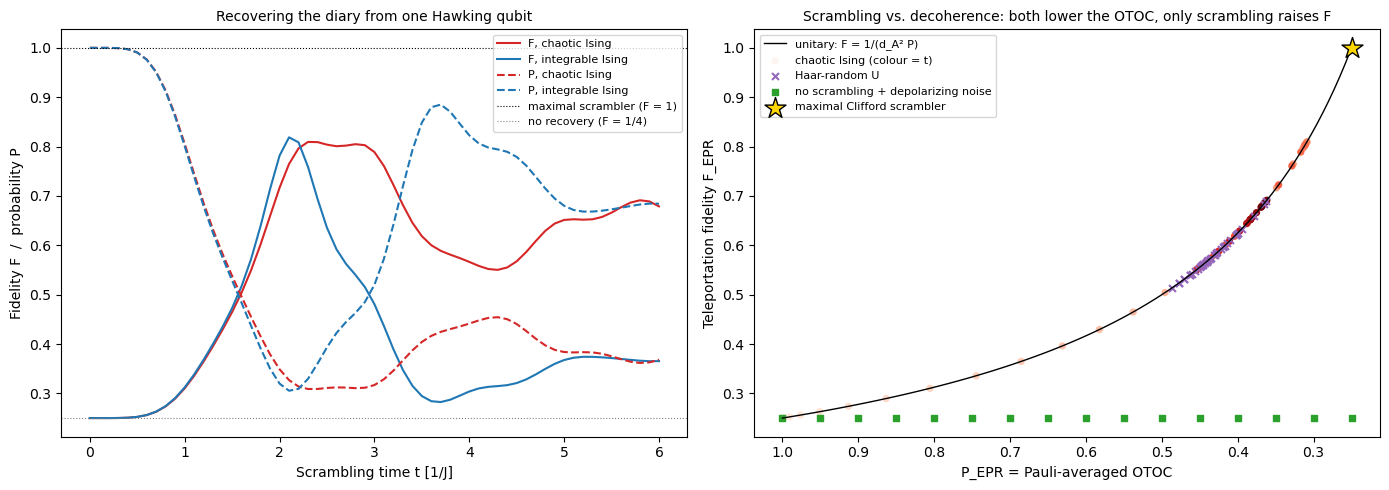

✅ Yoshida-Kitaev decoder (d_A = 2)
  Maximal scrambler:        P = 0.250, F = 1.000   (theory: P = 1/d_A² = 0.25, F = 1)
  Haar-random U (40 draws): F = 0.580 ± 0.041
  Chaotic Ising:            best F = 0.809 at t = 2.3
  Integrable Ising:         best F = 0.819
  Depolarizing noise p=0.75: P = 0.250 (OTOC decays), F = 0.250 (no recovery)
  Check F·d_A²·P = 1 for all unitaries: max deviation 3.3e-15


In [15]:
# 2. Black holes: Hayden-Preskill recovery via the Yoshida-Kitaev decoder (8-qubit simulation in cirq)
# Qubits: R (reference) - A (Alice's diary) - B1 B2 (black hole) | B1' B2' (early radiation, held by Bob) - A' R' (Bob's decoder pair)
from scipy.linalg import expm
from scipy.stats import unitary_group

R, A, B1, B2, B1p, B2p, Ap, Rp = cirq.LineQubit.range(8)
QUBITS = [R, A, B1, B2, B1p, B2p, Ap, Rp]

def bell_pair(a, b):
    return [cirq.H(a), cirq.CNOT(a, b)]

def bell_projector(a, b):
    """|Φ+><Φ+| on qubits (a, b) = (II + XX - YY + ZZ)/4, as a 256x256 matrix on all 8 qubits."""
    ps = (cirq.PauliString() + cirq.X(a) * cirq.X(b) - cirq.Y(a) * cirq.Y(b) + cirq.Z(a) * cirq.Z(b)) / 4
    return ps.matrix(QUBITS)

def hayden_preskill_circuit(U, noise=0.0):
    """Diary A (entangled with reference R) falls into black hole B, which is entangled with the early radiation B'.
    U scrambles (A, B1, B2); Bob applies U* to (A', B1', B2'). The Hawking qubit D = B2 is emitted."""
    c = cirq.Circuit(bell_pair(R, A), bell_pair(B1, B1p), bell_pair(B2, B2p), bell_pair(Ap, Rp))
    c.append(cirq.MatrixGate(U, name="U").on(A, B1, B2))
    if noise > 0:                                                     # decoherence inside the black hole
        c.append(cirq.depolarize(noise).on_each(A, B1, B2))
    c.append(cirq.MatrixGate(U.conj(), name="U*").on(Ap, B1p, B2p))
    return c

PROJ_D = bell_projector(B2, B2p)     # Bob's Bell measurement on the Hawking qubit D and its partner D'
PROJ_R = bell_projector(R, Rp)       # success check: is R' now entangled with R?
dm_sim = cirq.DensityMatrixSimulator(dtype=np.complex128)

def decode(U, noise=0.0):
    """Returns (P_EPR, F_EPR): probability of the Bell outcome on (D, D') and fidelity of (R, R') with |Φ+>."""
    rho = dm_sim.simulate(hayden_preskill_circuit(U, noise), qubit_order=QUBITS).final_density_matrix
    P = np.trace(PROJ_D @ rho).real
    F = np.trace(PROJ_R @ PROJ_D @ rho @ PROJ_D).real / P
    return P, F

# Scramblers: time evolution of the 3-qubit Ising chain from above, Haar-random unitaries, and a maximal Clifford scrambler
q3 = cirq.LineQubit.range(3)
U_MAX = cirq.Circuit(cirq.CZ(q3[0], q3[2]), cirq.CZ(q3[1], q3[2]), cirq.H.on_each(*q3),
                     cirq.CZ(q3[1], q3[2]), cirq.CZ(q3[0], q3[2])).unitary(qubit_order=q3)
bh_times = np.linspace(0, 6, 61)
res_chaos = np.array([decode(expm(-1j * ising_hamiltonian(3, H_X, H_Z) * t)) for t in bh_times])
res_int   = np.array([decode(expm(-1j * ising_hamiltonian(3, H_X, 0.0) * t)) for t in bh_times])
res_haar  = np.array([decode(unitary_group.rvs(8, random_state=s)) for s in range(40)])
res_noise = np.array([decode(np.eye(8), p) for p in np.linspace(0, 0.75, 16)])
P_max, F_max = decode(U_MAX)

print("Hayden-Preskill circuit with the maximal scrambler:")
print(hayden_preskill_circuit(U_MAX))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(bh_times, res_chaos[:, 1], c="tab:red", label="F, chaotic Ising")
axes[0].plot(bh_times, res_int[:, 1], c="tab:blue", label="F, integrable Ising")
axes[0].plot(bh_times, res_chaos[:, 0], c="tab:red", ls="--", label="P, chaotic Ising")
axes[0].plot(bh_times, res_int[:, 0], c="tab:blue", ls="--", label="P, integrable Ising")
axes[0].axhline(1, color="black", lw=0.8, ls=":", label="maximal scrambler (F = 1)")
axes[0].axhline(0.25, color="grey", lw=0.8, ls=":", label="no recovery (F = 1/4)")
axes[0].set_xlabel("Scrambling time t [1/J]")
axes[0].set_ylabel("Fidelity F  /  probability P")
axes[0].set_title("Recovering the diary from one Hawking qubit", fontsize=10)
axes[0].legend(fontsize=8)

PP = np.linspace(0.25, 1, 100)
axes[1].plot(PP, 1 / (4 * PP), c="black", lw=1, label="unitary: F = 1/(d_A² P)")
axes[1].scatter(res_chaos[:, 0], res_chaos[:, 1], c=bh_times, cmap="Reds", s=18, label="chaotic Ising (colour = t)")
axes[1].scatter(res_haar[:, 0], res_haar[:, 1], c="tab:purple", marker="x", s=25, label="Haar-random U")
axes[1].scatter(res_noise[:, 0], res_noise[:, 1], c="tab:green", marker="s", s=20, label="no scrambling + depolarizing noise")
axes[1].scatter([P_max], [F_max], c="gold", edgecolor="black", marker="*", s=250, zorder=5, label="maximal Clifford scrambler")
axes[1].set_xlabel("P_EPR = Pauli-averaged OTOC")
axes[1].set_ylabel("Teleportation fidelity F_EPR")
axes[1].set_title("Scrambling vs. decoherence: both lower the OTOC, only scrambling raises F", fontsize=10)
axes[1].invert_xaxis()
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

i_best = np.argmax(res_chaos[:, 1])
print(f"✅ Yoshida-Kitaev decoder (d_A = 2)")
print(f"  Maximal scrambler:        P = {P_max:.3f}, F = {F_max:.3f}   (theory: P = 1/d_A² = 0.25, F = 1)")
print(f"  Haar-random U (40 draws): F = {res_haar[:, 1].mean():.3f} ± {res_haar[:, 1].std():.3f}")
print(f"  Chaotic Ising:            best F = {res_chaos[i_best, 1]:.3f} at t = {bh_times[i_best]:.1f}")
print(f"  Integrable Ising:         best F = {res_int[:, 1].max():.3f}")
print(f"  Depolarizing noise p=0.75: P = {res_noise[-1, 0]:.3f} (OTOC decays), F = {res_noise[-1, 1]:.3f} (no recovery)")
print(f"  Check F·d_A²·P = 1 for all unitaries: max deviation {np.abs(4 * np.r_[res_chaos, res_int, res_haar].prod(axis=1) - 1).max():.1e}")

<font color="blue">*3. Page curve: entanglement between black hole and radiation*</font>

Page (PRL 71, 1291 (1993)) computed the average entanglement entropy of a subsystem of dimension $m \le k$ in a Haar-random pure state on $m k$ dimensions: $S = \sum_{j=k+1}^{mk} 1/j - (m-1)/(2k) \approx \ln m - m/(2k)$. Read the first $l$ qubits as Hawking radiation and the rest as the black hole. $S(\text{radiation})$ then rises by one bit per emitted qubit until the Page time $l = N/2$ and falls afterwards (the Page curve). For evaporation to be unitary, information must start to come out after the Page time. At $l = N/2$ the entropy stays $1/(2\ln 2) \approx 0.72$ bits below the maximum.

* **Left:** Page formula, Haar-random states and late-time states of the Ising chain ($N = 12$).
* **Right:** half-chain entropy after a quench from the product state $|{+i}\rangle^{\otimes N}$. This state has $\langle H \rangle = 0$, i.e. infinite temperature, so a chaotic chain should approach the Page value.

Results:

* **Page value at $l = N/2$:** 5.279 bits; Haar-random states give 5.274 bits.
* **Chaotic Ising:** 5.14 bits at late times, close to the Page value; its late-time Page curve lies on top of the Haar curve.
* **Integrable Ising:** about 2.8 bits and oscillating. The free-fermion chain does not thermalize to a random state; it relaxes to a generalized Gibbs ensemble with lower entropy.

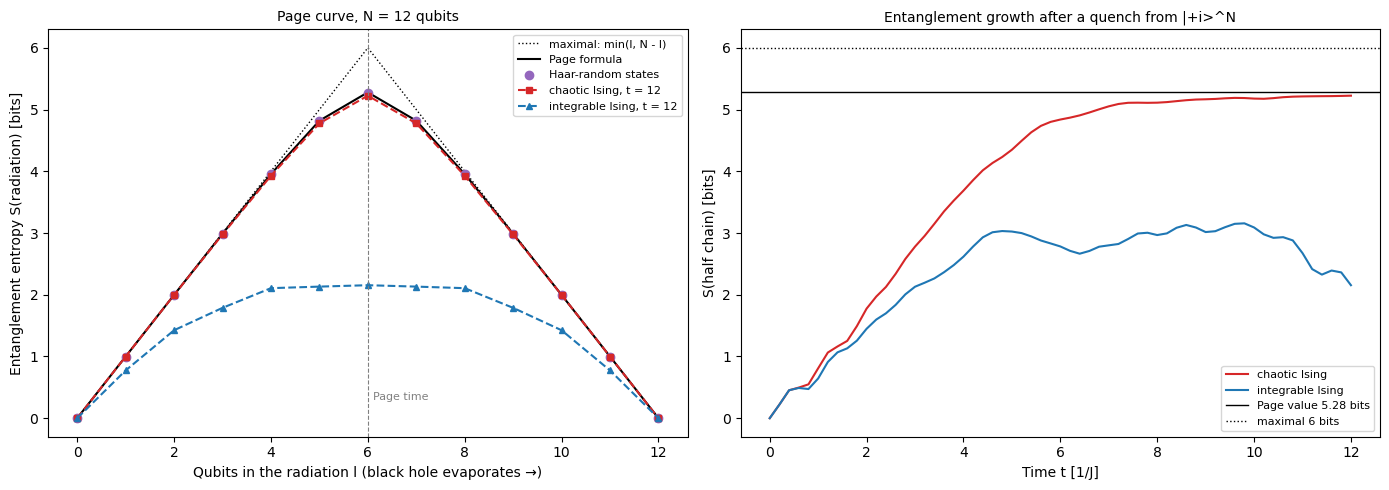

✅ Page curve (N = 12)
  Page value at l = N/2:   5.279 bits  (≈ N/2 - 1/(2 ln 2) = 5.279)
  Haar-random states:      5.274 bits
  Chaotic Ising, late t:   5.135 bits  (time average t > 6)
  Integrable Ising, late t:2.841 bits


In [16]:
# 5. Page curve: entanglement entropy of the "radiation" (first l qubits) vs. the "black hole" (the rest)
from scipy.sparse.linalg import expm_multiply
from scipy import sparse

def ising_hamiltonian_sparse(n, h_x, h_z, J=1.0):
    """Same Hamiltonian as above, as a sparse matrix (needed for n > 10)."""
    def op(o, j):
        return sparse.kron(sparse.kron(sparse.identity(2 ** j), sparse.csr_matrix(o)), sparse.identity(2 ** (n - j - 1)), format="csr")
    H = sum(J * op(Z, i) @ op(Z, i + 1) for i in range(n - 1))
    return H + sum(h_x * op(X, i) + h_z * op(Z, i) for i in range(n))

def entanglement_entropy(psi, l, n):
    """Von Neumann entropy (in bits) of the first l qubits of an n-qubit pure state."""
    if l in (0, n):
        return 0.0
    s = np.linalg.svd(psi.reshape(2 ** l, 2 ** (n - l)), compute_uv=False)
    p = s[s > 1e-12] ** 2
    return float(-(p * np.log2(p)).sum())

def page_entropy(l, n):
    """Page (1993): average entropy of a subsystem of dimension m <= k in a Haar-random state on m*k (in bits)."""
    m, k = sorted([2 ** l, 2 ** (n - l)])
    return (sum(1 / j for j in range(k + 1, m * k + 1)) - (m - 1) / (2 * k)) / np.log(2)

# --- Execution ---
N_PAGE = 12
ells = np.arange(N_PAGE + 1)
rng = np.random.default_rng(7)

# (a) Page curve: Haar-random states vs. Page's formula vs. the naive bound min(l, n - l)
haar_states = [(lambda v: v / np.linalg.norm(v))(rng.normal(size=2 ** N_PAGE) + 1j * rng.normal(size=2 ** N_PAGE)) for _ in range(5)]
S_haar = np.array([[entanglement_entropy(psi, l, N_PAGE) for l in ells] for psi in haar_states]).mean(axis=0)
S_page = np.array([page_entropy(l, N_PAGE) for l in ells])

# (b) Dynamics: half-chain entropy after a quench from the product state |+i>^N under the Ising chain from above
#     (<H> = 0 for this state, i.e. infinite temperature; |00...0> sits at the edge of the spectrum and entangles little)
page_times = np.linspace(0, 12, 61)
plus_i = np.array([1, 1j]) / np.sqrt(2)
psi_init = plus_i
for _ in range(N_PAGE - 1):
    psi_init = np.kron(psi_init, plus_i)
S_t = {}
for label, hz in [("chaotic", H_Z), ("integrable", 0.0)]:
    H_sp = ising_hamiltonian_sparse(N_PAGE, H_X, hz)
    states = expm_multiply(-1j * H_sp, psi_init, start=page_times[0], stop=page_times[-1], num=len(page_times), endpoint=True)
    S_t[label] = np.array([entanglement_entropy(psi, N_PAGE // 2, N_PAGE) for psi in states])
    S_t[label + "_curve"] = np.array([entanglement_entropy(states[-1], l, N_PAGE) for l in ells])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(ells, np.minimum(ells, N_PAGE - ells), "k:", lw=1, label="maximal: min(l, N - l)")
axes[0].plot(ells, S_page, "k-", lw=1.5, label="Page formula")
axes[0].plot(ells, S_haar, "o", c="tab:purple", label="Haar-random states")
axes[0].plot(ells, S_t["chaotic_curve"], "s--", c="tab:red", ms=5, label=f"chaotic Ising, t = {page_times[-1]:.0f}")
axes[0].plot(ells, S_t["integrable_curve"], "^--", c="tab:blue", ms=5, label=f"integrable Ising, t = {page_times[-1]:.0f}")
axes[0].axvline(N_PAGE / 2, color="grey", lw=0.8, ls="--")
axes[0].text(N_PAGE / 2 + 0.1, 0.3, "Page time", color="grey", fontsize=8)
axes[0].set_xlabel("Qubits in the radiation l (black hole evaporates →)")
axes[0].set_ylabel("Entanglement entropy S(radiation) [bits]")
axes[0].set_title(f"Page curve, N = {N_PAGE} qubits", fontsize=10)
axes[0].legend(fontsize=8)

axes[1].plot(page_times, S_t["chaotic"], c="tab:red", label="chaotic Ising")
axes[1].plot(page_times, S_t["integrable"], c="tab:blue", label="integrable Ising")
axes[1].axhline(page_entropy(N_PAGE // 2, N_PAGE), color="black", ls="-", lw=1, label=f"Page value {page_entropy(N_PAGE // 2, N_PAGE):.2f} bits")
axes[1].axhline(N_PAGE / 2, color="black", ls=":", lw=1, label=f"maximal {N_PAGE // 2} bits")
axes[1].set_xlabel("Time t [1/J]")
axes[1].set_ylabel(f"S(half chain) [bits]")
axes[1].set_title("Entanglement growth after a quench from |+i>^N", fontsize=10)
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

late = page_times > page_times[-1] / 2
print(f"✅ Page curve (N = {N_PAGE})")
print(f"  Page value at l = N/2:   {S_page[N_PAGE // 2]:.3f} bits  (≈ N/2 - 1/(2 ln 2) = {N_PAGE / 2 - 1 / (2 * np.log(2)):.3f})")
print(f"  Haar-random states:      {S_haar[N_PAGE // 2]:.3f} bits")
print(f"  Chaotic Ising, late t:   {S_t['chaotic'][late].mean():.3f} bits  (time average t > {page_times[-1] / 2:.0f})")
print(f"  Integrable Ising, late t:{S_t['integrable'][late].mean():.3f} bits")